## Setup & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plotting configuration
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
sns.set_style('whitegrid')
sns.set_palette('husl')


# Create images directory
IMAGES_PATH = Path('images') / 'eda'
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension='png', resolution=300):
    """Save figure to images directory"""
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution, bbox_inches='tight')
    print(f"✅ Saved: {path}")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)

%matplotlib inline

## 1. Load Data

In [3]:
# Data path
# data_path = Path('../../data/raw/bmw_pricing_challenge.csv')
data_path = Path('../../data/raw/bmw_pricing_challenge.csv')

# Load dataset
df = pd.read_csv(data_path)

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\n📊 Basic Statistics:")
print(f"   Rows: {len(df):,}")
print(f"   Columns: {df.shape[1]}")
print(f"   Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\n   Column Names:\n   {df.columns.tolist()}")


DATASET OVERVIEW

📊 Basic Statistics:
   Rows: 4,843
   Columns: 18
   Memory: 2.2 MB

   Column Names:
   ['maker_key', 'model_key', 'mileage', 'engine_power', 'registration_date', 'fuel', 'paint_color', 'car_type', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'price', 'sold_at']


In [4]:
# Display first rows
print("\nFirst 5 Rows:")
df.head()


First 5 Rows:


,maker_key,model_key,mileage,engine_power,registration_date,fuel,paint_color,car_type,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,price,sold_at
0,BMW,118,140411,100,2012-02-01,diesel,black,convertible,True,True,False,False,True,True,True,False,11300,2018-01-01
1,BMW,M4,13929,317,2016-04-01,petrol,grey,convertible,True,True,False,False,False,True,True,True,69700,2018-02-01
2,BMW,320,183297,120,2012-04-01,diesel,white,convertible,False,False,False,False,True,False,True,False,10200,2018-02-01
3,BMW,420,128035,135,2014-07-01,diesel,red,convertible,True,True,False,False,True,True,True,True,25100,2018-02-01
4,BMW,425,97097,160,2014-12-01,diesel,silver,convertible,True,True,False,False,False,True,True,True,33400,2018-04-01


In [5]:
# Data types
print("\nData Types:")
print(df.dtypes)
print(f"\nData Info:")
df.info()


Data Types:
maker_key            object
model_key            object
mileage               int64
engine_power          int64
registration_date    object
fuel                 object
paint_color          object
car_type             object
feature_1              bool
feature_2              bool
feature_3              bool
feature_4              bool
feature_5              bool
feature_6              bool
feature_7              bool
feature_8              bool
price                 int64
sold_at              object
dtype: object

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   maker_key          4843 non-null   object
 1   model_key          4843 non-null   object
 2   mileage            4843 non-null   int64 
 3   engine_power       4843 non-null   int64 
 4   registration_date  4843 non-null   object
 5   fuel            

## 2. Schema Validation

**Checking:**
- Expected columns present
- Minimum row count (>1,000 for meaningful ML)
- Data types are appropriate

In [6]:
# Expected schema
expected_cols = [
    'model_key', 'mileage', 'engine_power', 'registration_date',
    'fuel', 'paint_color', 'car_type', 'price'
] + [f'feature_{i}' for i in range(1, 9)]

print("\n" + "=" * 80)
print("SCHEMA VALIDATION")
print("=" * 80)

# Check columns
missing_cols = set(expected_cols) - set(df.columns)
extra_cols = set(df.columns) - set(expected_cols)

if len(missing_cols) == 0:
    print("\n✅ All expected columns present")
else:
    print(f"\n❌ Missing columns: {missing_cols}")

if len(extra_cols) > 0:
    print(f"ℹ️  Extra columns found: {extra_cols}")

# Check row count
if len(df) >= 1000:
    print(f"\n✅ Sufficient data: {len(df):,} rows (>1,000 minimum for ML)")
else:
    print(f"\n⚠️  Insufficient data: {len(df):,} rows (<1,000 minimum)")


SCHEMA VALIDATION

✅ All expected columns present
ℹ️  Extra columns found: {'maker_key', 'sold_at'}

✅ Sufficient data: 4,843 rows (>1,000 minimum for ML)


## 3. Data Quality Checks

**Check whether the data is valid:** No missing data, no identical or illogical values. All must be sufficiently diverse
- ❌ All prices identical → Data corruption
- ❌ Mileage all zeros → Missing data
- ❌ Only one registration year → Insufficient diversity
- ❌ Future dates → Data error

**Expected Ranges (BMW Market):**
- Price: €5K - €100K
- Mileage: 0 - 300K km
- Years: 5-15 year span

In [7]:
print("\n" + "=" * 80)
print("DATA QUALITY SANITY CHECKS")
print("=" * 80)

# Price range
price_min, price_max = df['price'].min(), df['price'].max()
print(f"\n💰 Price Range: €{price_min:,.0f} - €{price_max:,.0f}")
if 5000 <= price_min and price_max <= 100000:
    print("   ✅ Reasonable for BMW used cars (€5K - €100K expected)")
elif price_max > 100000:
    print(f"   ⚠️  Some luxury/rare models detected (max: €{price_max:,.0f})")
else:
    print("   ⚠️  Price range unusual - investigate")

# Mileage range
mileage_min, mileage_max = df['mileage'].min(), df['mileage'].max()
print(f"\n🚗 Mileage Range: {mileage_min:,.0f} - {mileage_max:,.0f} km")
if 0 <= mileage_min and mileage_max <= 300000:
    print("   ✅ Reasonable range (0 - 300K km expected)")
else:
    print("   ⚠️  Mileage range unusual - check for errors")

# Price diversity (corruption check)
unique_prices = df['price'].nunique()
if unique_prices == 1:
    print("\n❌ RED FLAG: All prices are identical! Data corruption detected.")
else:
    print(f"\n✅ Price diversity: {unique_prices:,} unique values ({unique_prices/len(df)*100:.1f}% unique)")

# Mileage zeros (new cars vs missing data)
zero_mileage = (df['mileage'] == 0).sum()
zero_mileage_pct = zero_mileage / len(df) * 100
if zero_mileage_pct == 100:
    print("\n❌ RED FLAG: All mileage values are zero! Missing data issue.")
elif zero_mileage_pct > 10:
    print(f"\n⚠️  High proportion of zero mileage: {zero_mileage_pct:.1f}% ({zero_mileage:,} cars)")
    print("   → Could be new cars or data quality issue")
else:
    print(f"\n✅ Mileage variation present ({zero_mileage_pct:.1f}% zeros - likely new cars)")


DATA QUALITY SANITY CHECKS

💰 Price Range: €100 - €178,500
   ⚠️  Some luxury/rare models detected (max: €178,500)

🚗 Mileage Range: -64 - 1,000,376 km
   ⚠️  Mileage range unusual - check for errors

✅ Price diversity: 437 unique values (9.0% unique)

✅ Mileage variation present (0.0% zeros - likely new cars)


In [8]:
# Temporal checks
df['registration_date'] = pd.to_datetime(df['registration_date'], errors='coerce')
df['registration_year'] = df['registration_date'].dt.year

year_min, year_max = df['registration_year'].min(), df['registration_year'].max()
year_span = year_max - year_min
current_year = pd.Timestamp.now().year

print(f"\n📅 Registration Years: {year_min} - {year_max} ({year_span} year span)")

if year_span >= 5:
    print(f"   ✅ Good temporal diversity ({year_span} years)")
elif year_span >= 3:
    print(f"   ⚠️  Moderate diversity ({year_span} years) - acceptable")
else:
    print(f"   ⚠️  Limited temporal span ({year_span} years) - may lack diversity")

# Future dates check
if year_max > current_year:
    future_dates = df[df['registration_year'] > current_year]
    print(f"\n❌ RED FLAG: {len(future_dates):,} future dates detected (max year: {year_max})")
    print(f"   → DATA ERROR: Registration dates cannot be in the future")
else:
    print(f"\n✅ No future dates (max year: {year_max})")

# Very old cars check
very_old = df[df['registration_year'] < 1990]
if len(very_old) > 0:
    print(f"\n⚠️  {len(very_old):,} very old cars (pre-1990)")
    print(f"   → Could be classic cars or data errors - investigate")


📅 Registration Years: 1990 - 2017 (27 year span)
   ✅ Good temporal diversity (27 years)

✅ No future dates (max year: 2017)


In [9]:
# Model key validation
print(f"\n🏎️  Model Keys (top 15):")
model_counts = df['model_key'].value_counts().head(15)
print(model_counts)

# Check for common BMW models
common_bmw = ['318', '320', '325', '330', '520', '530', 'X3', 'X5', 'X1']
found_models = [m for m in common_bmw if df['model_key'].astype(str).str.contains(m, na=False).any()]

if len(found_models) > 0:
    print(f"\n✅ Common BMW models found: {found_models}")
else:
    print(f"\n⚠️  No common BMW codes detected - verify model_key encoding")


🏎️  Model Keys (top 15):
model_key
320                 752
520                 633
318                 569
X3                  438
116                 358
X1                  275
316                 235
X5                  231
525                 184
530                 157
118                 143
318 Gran Turismo     97
320 Gran Turismo     73
518                  66
535                  46
Name: count, dtype: int64

✅ Common BMW models found: ['318', '320', '325', '330', '520', '530', 'X3', 'X5', 'X1']


## 4. Missing Data Analysis

**Decision Framework:**
- < 5% missing → Acceptable (impute or drop rows)
- 5-20% missing → Requires imputation strategy
- \> 20% missing → Critical (consider dropping column)

In [10]:
print("\n" + "=" * 80)
print("MISSING DATA ANALYSIS")
print("=" * 80)

# Calculate missing percentages
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

if len(missing_pct) == 0:
    print("\n✅ NO MISSING DATA DETECTED")
    print("   → Excellent data quality, proceed with analysis")
else:
    print("\n⚠️  MISSING DATA DETECTED:\n")
    
    # Create summary table
    missing_summary = pd.DataFrame({
        'Missing Count': missing_counts[missing_pct.index],
        'Missing %': missing_pct,
        'Data Type': df[missing_pct.index].dtypes
    })
    print(missing_summary)
    
    # Provide recommendations
    print("\n📋 Recommendations:")
    for col, pct in missing_pct.items():
        if pct > 20:
            print(f"   🚨 CRITICAL - {col}: {pct:.1f}% missing")
            print(f"      → Consider dropping column or investigate why so much missing")
        elif pct > 5:
            print(f"   ⚠️  WARNING - {col}: {pct:.1f}% missing")
            print(f"      → Requires imputation strategy (median/mode/domain knowledge)")
        else:
            print(f"   ℹ️  MINOR - {col}: {pct:.1f}% missing")
            print(f"      → Can drop rows or simple imputation")


MISSING DATA ANALYSIS

✅ NO MISSING DATA DETECTED
   → Excellent data quality, proceed with analysis


In [11]:
# Visualize missing data if present
if len(missing_pct) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Create bar plot
    colors = ['darkred' if x > 20 else 'orange' if x > 5 else 'gold' for x in missing_pct]
    missing_pct.plot(kind='barh', ax=ax, color=colors)
    
    # Add threshold lines
    ax.axvline(5, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='5% threshold')
    ax.axvline(20, color='darkred', linestyle='--', linewidth=2, alpha=0.7, label='20% threshold')
    
    ax.set_xlabel('Missing Data (%)', fontsize=12)
    ax.set_title('Missing Data by Column', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()
    
    save_fig('01_missing_data')
    plt.show()
else:
    print("✅ No missing data to visualize")

✅ No missing data to visualize


## 5. Statistical Summary

Understanding distributions, central tendencies, and spread

In [12]:
# Numeric features summary
print("\n" + "=" * 80)
print("STATISTICAL SUMMARY (Numeric Features)")
print("=" * 80)
df.describe()


STATISTICAL SUMMARY (Numeric Features)


,mileage,engine_power,registration_date,price,registration_year
count,4843.00,4843.00,4843,4843.00,4843.00
mean,140962.80,128.99,2012-11-22 14:51:42.704934912,15828.08,2012.47
min,-64.00,0.00,1990-03-01 00:00:00,100.00,1990.00
25%,102913.50,100.00,2012-07-01 00:00:00,10800.00,2012.00
50%,141080.00,120.00,2013-07-01 00:00:00,14200.00,2013.00
75%,175195.50,135.00,2014-04-01 00:00:00,18600.00,2014.00
max,1000376.00,423.00,2017-11-01 00:00:00,178500.00,2017.00
std,60196.74,38.99,NaN,9220.29,2.53


In [13]:
# Categorical features summary
print("\n" + "=" * 80)
print("CATEGORICAL FEATURES DISTRIBUTION")
print("=" * 80)

categorical_cols = ['fuel', 'car_type', 'paint_color']

for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col.upper()}:")
        print("-" * 40)
        
        value_counts = df[col].value_counts()
        value_pcts = df[col].value_counts(normalize=True) * 100
        
        # Combine into summary
        summary = pd.DataFrame({
            'Count': value_counts,
            'Percentage': value_pcts.round(1)
        })
        print(summary)
        
        # Flag rare classes (<5%)
        rare_classes = value_pcts[value_pcts < 5]
        if len(rare_classes) > 0:
            print(f"\n   ⚠️  {len(rare_classes)} rare classes (<5%): {list(rare_classes.index)}")
            print(f"   → RECOMMENDATION: Consider grouping or target encoding for ML")


CATEGORICAL FEATURES DISTRIBUTION

FUEL:
----------------------------------------
               Count  Percentage
fuel                            
diesel          4641       95.80
petrol           191        3.90
hybrid_petrol      8        0.20
electro            3        0.10

   ⚠️  3 rare classes (<5%): ['petrol', 'hybrid_petrol', 'electro']
   → RECOMMENDATION: Consider grouping or target encoding for ML

CAR_TYPE:
----------------------------------------
             Count  Percentage
car_type                      
estate        1606       33.20
sedan         1168       24.10
suv           1058       21.80
hatchback      699       14.40
subcompact     117        2.40
coupe          104        2.10
convertible     47        1.00
van             44        0.90

   ⚠️  4 rare classes (<5%): ['subcompact', 'coupe', 'convertible', 'van']
   → RECOMMENDATION: Consider grouping or target encoding for ML

PAINT_COLOR:
----------------------------------------
             Count  Percent

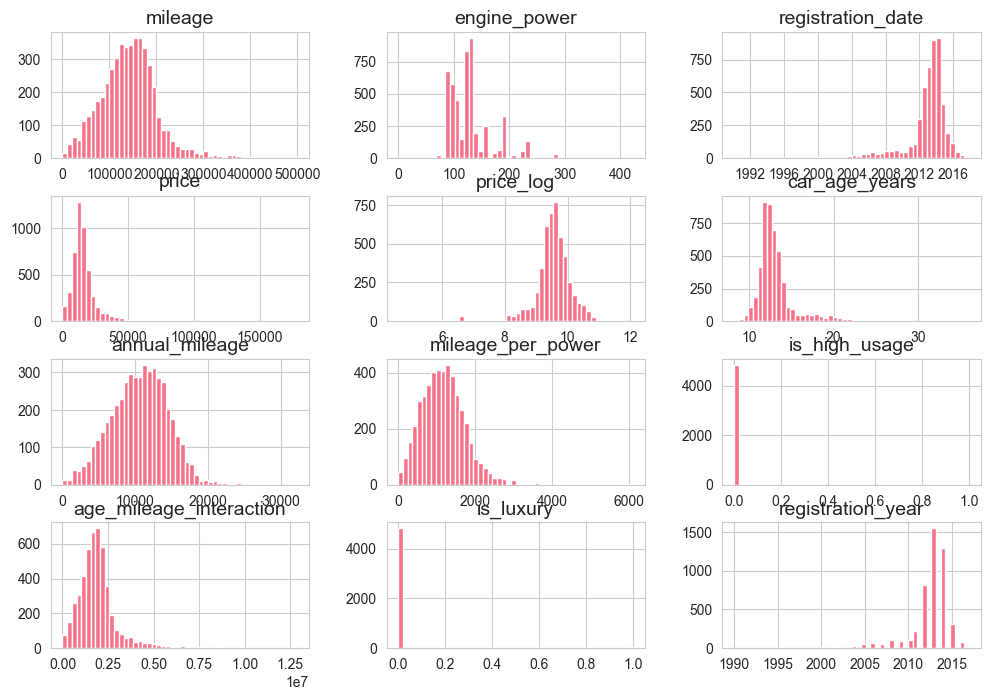

In [108]:
df.hist(bins=50, figsize=(12, 8))
plt.show()

## 6. Summary Report & Decision

**Next Steps:**
- ✅ All checks pass → Proceed to Feature Analysis (02-feature-analysis.ipynb)
- ⚠️  Warnings present → Document and handle in preprocessing
- ❌ Critical issues → Stop and fix data problems

In [14]:
print("\n" + "=" * 80)
print("DATA EXPLORATION SUMMARY & DECISION")
print("=" * 80)

# Collect issues
critical_issues = []
warnings_list = []
passes = []

# Schema
if len(missing_cols) == 0:
    passes.append("All expected columns present")
else:
    critical_issues.append(f"Missing columns: {missing_cols}")

# Sample size
if len(df) >= 1000:
    passes.append(f"Sufficient data ({len(df):,} rows)")
else:
    critical_issues.append(f"Insufficient data ({len(df):,} rows < 1,000)")

# Price range
if 5000 <= price_min and price_max <= 100000:
    passes.append("Price range reasonable (€5K-€100K)")
elif price_max > 100000:
    warnings_list.append(f"Some prices > €100K (max: €{price_max:,.0f})")
else:
    warnings_list.append("Price range unusual")

# Mileage
if 0 <= mileage_min and mileage_max <= 300000:
    passes.append("Mileage range reasonable (0-300K km)")
else:
    warnings_list.append("Mileage range unusual")

# Temporal span
if year_span >= 5:
    passes.append(f"Good temporal diversity ({year_span} years)")
elif year_span >= 3:
    warnings_list.append(f"Moderate temporal diversity ({year_span} years)")
else:
    warnings_list.append(f"Limited temporal span ({year_span} years)")

# Future dates
if year_max <= current_year:
    passes.append("No future dates detected")
else:
    critical_issues.append(f"Future dates detected (max: {year_max})")

# Missing data
if len(missing_pct) == 0:
    passes.append("No missing data")
else:
    critical_missing = missing_pct[missing_pct > 20]
    if len(critical_missing) > 0:
        critical_issues.append(f"Critical missing data (>20%): {list(critical_missing.index)}")
    else:
        moderate_missing = missing_pct[missing_pct > 5]
        if len(moderate_missing) > 0:
            warnings_list.append(f"Moderate missing data (5-20%): {list(moderate_missing.index)}")
        else:
            warnings_list.append(f"Minor missing data (<5%)")

# Print summary
print("\n✅ PASSED CHECKS:")
for p in passes:
    print(f"   • {p}")

if warnings_list:
    print("\n⚠️  WARNINGS (Document & Handle):")
    for w in warnings_list:
        print(f"   • {w}")

if critical_issues:
    print("\n❌ CRITICAL ISSUES (Must Fix):")
    for i in critical_issues:
        print(f"   • {i}")
    print("\n" + "=" * 80)
    print("⛔ DO NOT PROCEED - FIX DATA ISSUES FIRST")
    print("=" * 80)
else:
    print("\n" + "=" * 80)
    print("✅ DATA QUALITY CHECK: PASSED")
    print("=" * 80)
    print("\n📊 Dataset is ready for analysis")
    print("\nNext Steps:")
    print("   1. Run 02-feature-analysis.ipynb for correlation analysis")
    print("   2. Analyze price distribution and target variable")
    print("   3. Identify strong predictors for model training")
    print("\nBusiness Goal Alignment:")
    print("   • Target: Reduce mispricing from 25% to 15% (TR < 15%)")
    print("   • Target MAE: €1,500 - €2,500")
    print("   • Target R²: ≥ 0.85")
    print("   • Expected savings: €322K/year")


DATA EXPLORATION SUMMARY & DECISION

✅ PASSED CHECKS:
   • All expected columns present
   • Sufficient data (4,843 rows)
   • Good temporal diversity (27 years)
   • No future dates detected
   • No missing data

⚠️  WARNINGS (Document & Handle):
   • Some prices > €100K (max: €178,500)
   • Mileage range unusual

✅ DATA QUALITY CHECK: PASSED

📊 Dataset is ready for analysis

Next Steps:
   1. Run 02-feature-analysis.ipynb for correlation analysis
   2. Analyze price distribution and target variable
   3. Identify strong predictors for model training

Business Goal Alignment:
   • Target: Reduce mispricing from 25% to 15% (TR < 15%)
   • Target MAE: €1,500 - €2,500
   • Target R²: ≥ 0.85
   • Expected savings: €322K/year


## 7. Generate Reports 📄

**Output:**
1. HTML Report (professional, shareable)
2. Text Summary (for documentation)
3. Console output (above)

In [110]:
from datetime import datetime

def generate_html_report():
    """Generate HTML report"""
    report_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    html = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>BMW Pricing - Data Quality Report</title>
    <style>
        body {{
            font-family: 'Segoe UI', sans-serif;
            max-width: 1200px;
            margin: 40px auto;
            padding: 20px;
            background: #f5f5f5;
        }}
        .header {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 30px;
            border-radius: 10px;
            margin-bottom: 30px;
        }}
        .header h1 {{ margin: 0; font-size: 2.5em; }}
        .section {{
            background: white;
            padding: 25px;
            margin-bottom: 20px;
            border-radius: 8px;
            box-shadow: 0 2px 4px rgba(0,0,0,0.08);
        }}
        .section h2 {{
            color: #667eea;
            border-bottom: 3px solid #667eea;
            padding-bottom: 10px;
        }}
        .metric {{
            display: inline-block;
            background: #f8f9fa;
            padding: 15px 20px;
            margin: 10px 10px 10px 0;
            border-radius: 6px;
            border-left: 4px solid #667eea;
        }}
        .metric-label {{ font-size: 0.85em; color: #666; }}
        .metric-value {{ font-size: 1.8em; font-weight: bold; margin-top: 5px; }}
        .status {{ padding: 5px 12px; border-radius: 4px; font-weight: bold; }}
        .status-pass {{ background: #d4edda; color: #155724; }}
        .status-warn {{ background: #fff3cd; color: #856404; }}
        .status-fail {{ background: #f8d7da; color: #721c24; }}
        table {{ width: 100%; border-collapse: collapse; margin: 20px 0; }}
        th {{ background: #667eea; color: white; padding: 12px; text-align: left; }}
        td {{ padding: 10px 12px; border-bottom: 1px solid #ddd; }}
        ul {{ line-height: 1.8; }}
    </style>
</head>
<body>
    <div class="header">
        <h1>📊 BMW Pricing Challenge</h1>
        <h2>Data Quality Assessment Report</h2>
        <p>Generated: {report_time}</p>
    </div>
    
    <div class="section">
        <h2>📈 Executive Summary</h2>
        <div class="metric">
            <div class="metric-label">Rows</div>
            <div class="metric-value">{len(df):,}</div>
        </div>
        <div class="metric">
            <div class="metric-label">Columns</div>
            <div class="metric-value">{df.shape[1]}</div>
        </div>
        <div class="metric">
            <div class="metric-label">Price Range</div>
            <div class="metric-value">€{price_min:,.0f} - €{price_max:,.0f}</div>
        </div>
    </div>
    
    <div class="section">
        <h2>✓ Quality Checks</h2>
        <table>
            <tr><th>Check</th><th>Status</th><th>Details</th></tr>
    """
    
    # Add checks
    if len(missing_cols) == 0:
        html += '<tr><td>Schema</td><td><span class="status status-pass">✓ PASS</span></td><td>All columns present</td></tr>'
    else:
        html += f'<tr><td>Schema</td><td><span class="status status-fail">✗ FAIL</span></td><td>Missing cols</td></tr>'
    
    if len(df) >= 1000:
        html += f'<tr><td>Sample Size</td><td><span class="status status-pass">✓ PASS</span></td><td>{len(df):,} rows</td></tr>'
    else:
        html += f'<tr><td>Sample Size</td><td><span class="status status-fail">✗ FAIL</span></td><td>{len(df):,} rows</td></tr>'
    
    if 5000 <= price_min and price_max <= 100000:
        html += f'<tr><td>Price Range</td><td><span class="status status-pass">✓ PASS</span></td><td>€{price_min:,.0f} - €{price_max:,.0f}</td></tr>'
    else:
        html += f'<tr><td>Price Range</td><td><span class="status status-warn">⚠ WARN</span></td><td>Unusual</td></tr>'
    
    if len(missing_pct) == 0:
        html += '<tr><td>Missing Data</td><td><span class="status status-pass">✓ PASS</span></td><td>None</td></tr>'
    else:
        html += f'<tr><td>Missing Data</td><td><span class="status status-warn">⚠ WARN</span></td><td>{len(missing_pct)} columns</td></tr>'
    
    html += "</table></div>"
    
    # Summary
    html += '<div class="section"><h2>💡 Summary</h2><ul>'
    for p in passes:
        html += f'<li>✅ {p}</li>'
    for w in warnings_list:
        html += f'<li>⚠️ {w}</li>'
    for i in critical_issues:
        html += f'<li>❌ {i}</li>'
    html += '</ul>'
    
    if len(critical_issues) == 0:
        html += '<p style="background:#d4edda;padding:15px;border-radius:5px;"><strong>✅ PASSED</strong> - Ready for analysis</p>'
    else:
        html += '<p style="background:#f8d7da;padding:15px;border-radius:5px;"><strong>❌ FAILED</strong> - Fix issues first</p>'
    
    html += '</div></body></html>'
    
    return html

# Generate
html_path =  'data_quality_report.html'
with open(html_path, 'w') as f:
    f.write(generate_html_report())

print(f"\n✅ HTML Report: {html_path}")


✅ HTML Report: data_quality_report.html


In [111]:
# Text summary
txt_path = 'data_quality_summary.txt'

with open(txt_path, 'w') as f:
    f.write(f"""BMW PRICING - DATA QUALITY SUMMARY
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*80}

DATASET
{'-'*80}
Rows: {len(df):,}
Columns: {df.shape[1]}
Price: €{price_min:,.0f} - €{price_max:,.0f}

FINDINGS
{'-'*80}
""")
    
    for p in passes:
        f.write(f"✅ {p}\n")
    for w in warnings_list:
        f.write(f"⚠️  {w}\n")
    for i in critical_issues:
        f.write(f"❌ {i}\n")
    
    if len(critical_issues) == 0:
        f.write("\n✅ READY FOR ANALYSIS\n")
    else:
        f.write("\n❌ FIX ISSUES FIRST\n")

print(f"✅ Text Summary: {txt_path}")
print(f"\n📊 Open reports in browser or text editor")

✅ Text Summary: data_quality_summary.txt

📊 Open reports in browser or text editor
